# 02 - EDA Sales Analysis

This notebook analyzes the sales performance of the Global Superstore dataset.

The goal is to understand:

- Sales evolution over time.
- Yearly and monthly sales trends.
- Sales distribution by market and region.
- Sales by category and sub-category.
- Sales by customer segment.
- Top products by sales.
- Initial business insights from sales performance.

Important note:

Sales alone do not represent profitability. For that reason, this notebook also includes `profit` and `profit_margin` as supporting metrics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from superstore.data.loader import load_processed_data
from superstore.analytics.sales import (
    sales_by_year,
    sales_by_month,
    sales_by_market,
    sales_by_market_group,
    sales_by_region,
    sales_by_country,
    sales_by_category,
    sales_by_sub_category,
    sales_by_segment,
    top_products_by_sales,
)

In [2]:
# Notebook settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")

In [3]:
# Load Data

df = load_processed_data()

df.head()

,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,product_id,product_name,profit,quantity,region,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,market_group,week_number,order_year,order_month,order_month_name,order_quarter,order_weekday,shipping_days,profit_margin,is_loss,discount_level
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0000,US,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,19,Consumer,2011-01-09,Second Class,4.3700,California,Paper,2011,North America,2,2011,1,January,1,Friday,2,0.4911,False,no_discount
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0000,US,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,19,Consumer,2011-01-26,Standard Class,0.9400,California,Paper,2011,North America,4,2011,1,January,1,Friday,5,0.4891,False,no_discount
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0000,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,21,Consumer,2011-08-09,Standard Class,1.8100,California,Paper,2011,North America,32,2011,8,August,3,Friday,4,0.4687,False,no_discount
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0000,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,111,Consumer,2011-08-09,Standard Class,4.5900,California,Paper,2011,North America,32,2011,8,August,3,Friday,4,0.4798,False,no_discount
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0000,US,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,6,Consumer,2011-10-03,Standard Class,1.3200,California,Paper,2011,North America,40,2011,9,September,3,Thursday,4,0.5184,False,no_discount


In [4]:
# Helper function para formato
#########
# Esto nos ayuda para mostrar tablas mas legibles sin cambiar los datos originales
#########

def format_currency(value: float) -> str:
    return f"${value:,.2f}"


def format_percentage(value: float) -> str:
    return f"{value:.2%}"


def format_sales_table(data: pd.DataFrame) -> pd.DataFrame:
    formatted = data.copy()

    currency_columns = [
        "total_sales",
        "total_profit",
        "average_order_value",
    ]

    percentage_columns = [
        "profit_margin",
        "sales_growth_rate",
        "profit_growth_rate",
        "orders_growth_rate",
    ]

    for column in currency_columns:
        if column in formatted.columns:
            formatted[column] = formatted[column].apply(format_currency)

    for column in percentage_columns:
        if column in formatted.columns:
            formatted[column] = formatted[column].apply(
                lambda value: "" if pd.isna(value) else format_percentage(value)
            )

    return formatted

## 1. Sales by year

We start by analyzing annual sales performance.

This helps answer:

- Is the business growing?
- Are sales increasing year over year?
- Is profit growing at the same pace as sales?
- Are orders increasing?

In [6]:
# Sales by year table

yearly_sales = sales_by_year(df)

format_sales_table(yearly_sales)

,order_year,total_sales,total_profit,total_orders,total_quantity,sales_growth_rate,profit_growth_rate,orders_growth_rate
0,2011,"$2,259,511.00","$248,940.81",4440,31443,,,
1,2012,"$2,677,493.00","$307,415.28",5343,38111,18.50%,23.49%,20.34%
2,2013,"$3,405,860.00","$406,935.23",6721,48136,27.20%,32.37%,25.79%
3,2014,"$4,300,041.00","$504,165.97",8531,60622,26.25%,23.89%,26.93%


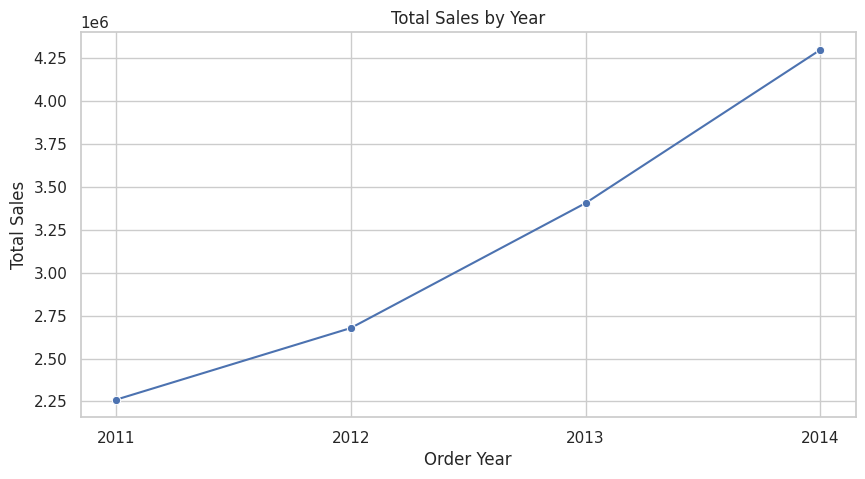

In [7]:
# Sales by year chart

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly_sales,
    x="order_year",
    y="total_sales",
    marker="o"
)

plt.title("Total Sales by Year")
plt.xlabel("Order Year")
plt.ylabel("Total Sales")
plt.xticks(yearly_sales["order_year"])
plt.show()

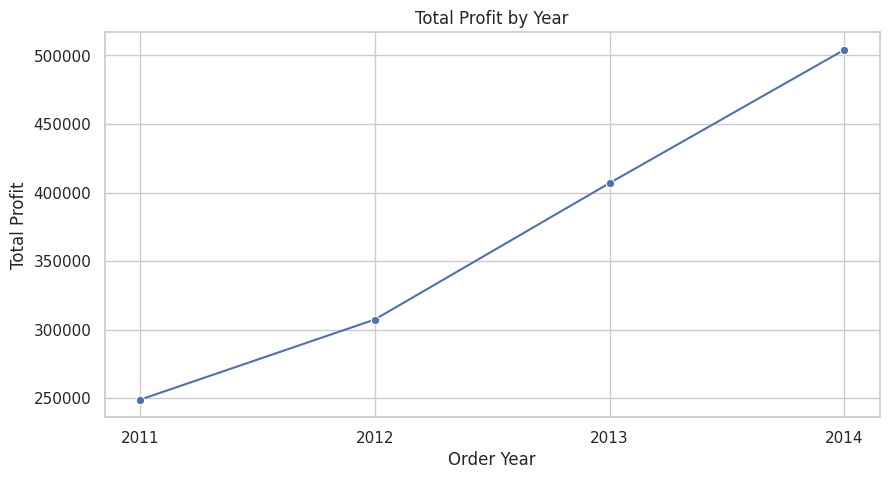

In [9]:
# Profit by year chart

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_sales,
    x="order_year",
    y="total_profit",
    marker="o",
)

plt.title("Total Profit by Year")
plt.xlabel("Order Year")
plt.ylabel("Total Profit")
plt.xticks(yearly_sales["order_year"])
plt.show()

### Initial yearly sales insight

The business shows consistent growth from 2011 to 2014.

Sales, profit, orders and quantity increased every year. The strongest relative growth happened in 2013, where profit grew faster than sales.

In 2014, sales continued growing strongly, but profit growth was slightly lower than sales growth. This may suggest margin pressure, discount impact, logistics cost impact or a less profitable product mix.


## 2. Monthly sales trend

Monthly sales help identify seasonality, volatility and periods where sales and profit move differently.

In [11]:
# Sales by month

monthly_sales = sales_by_month(df)

monthly_sales.head()

,order_year,order_month,order_month_name,total_sales,total_profit,total_orders,total_quantity,period,sales_growth_rate,profit_growth_rate
0,2011,1,January,98902,"8,321.8010",216,1463,2011-01,NaN,NaN
1,2011,2,February,91152,"12,417.9070",183,1224,2011-02,-0.0784,0.4922
2,2011,3,March,145726,"15,303.5683",277,1836,2011-03,0.5987,0.2324
3,2011,4,April,116927,"12,902.3244",267,2020,2011-04,-0.1976,-0.1569
4,2011,5,May,146762,"12,183.8287",295,2013,2011-05,0.2552,-0.0557


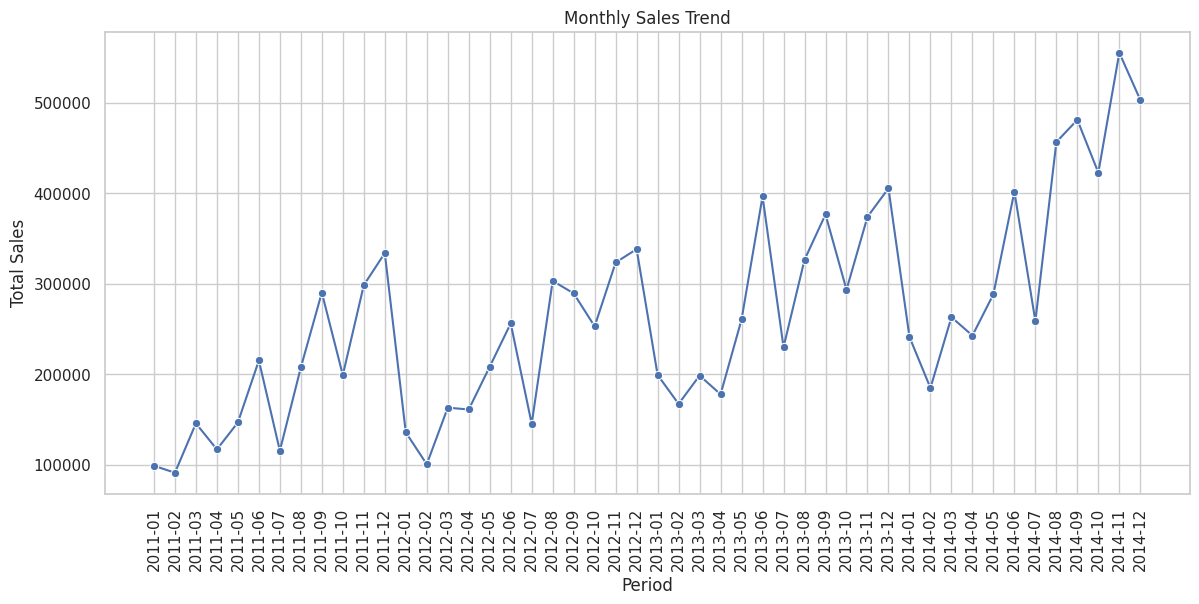

In [12]:
# MOnthly sales chart

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="period",
    y="total_sales",
    marker="o",
)

plt.title("Monthly Sales Trend")
plt.xlabel("Period")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

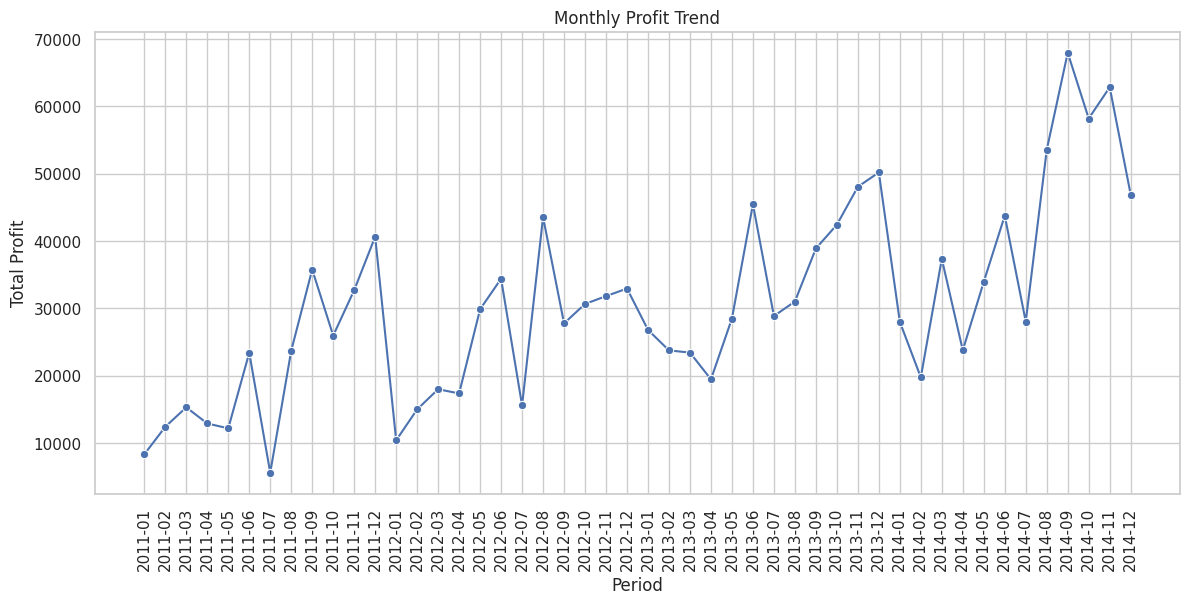

In [13]:
# Monthly profit chart

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="period",
    y="total_profit",
    marker="o",
)

plt.title("Monthly Profit Trend")
plt.xlabel("Period")
plt.ylabel("Total Profit")
plt.xticks(rotation=90)
plt.show()

In [14]:
# Monthly growth table

monthly_growth_preview = monthly_sales[
    [
        "period",
        "total_sales",
        "total_profit",
        "sales_growth_rate",
        "profit_growth_rate",
    ]
].head(12)

format_sales_table(monthly_growth_preview)

,period,total_sales,total_profit,sales_growth_rate,profit_growth_rate
0,2011-01,"$98,902.00","$8,321.80",,
1,2011-02,"$91,152.00","$12,417.91",-7.84%,49.22%
2,2011-03,"$145,726.00","$15,303.57",59.87%,23.24%
3,2011-04,"$116,927.00","$12,902.32",-19.76%,-15.69%
4,2011-05,"$146,762.00","$12,183.83",25.52%,-5.57%
5,2011-06,"$215,214.00","$23,415.25",46.64%,92.18%
6,2011-07,"$115,518.00","$5,585.00",-46.32%,-76.15%
7,2011-08,"$207,570.00","$23,713.67",79.69%,324.60%
8,2011-09,"$290,230.00","$35,776.88",39.82%,50.87%
9,2011-10,"$199,070.00","$25,963.42",-31.41%,-27.43%


### Initial monthly sales insight

Monthly performance is more volatile than annual performance.

There are months where sales increase but profit does not increase at the same pace, or even decreases. This suggests that sales growth alone is not enough to evaluate business health.

Further analysis should compare monthly sales with discounts, product mix and shipping costs.

## 3. Sales by market

Market analysis helps identify where the business generates most of its commercial volume.

This section compares:

- Total sales.
- Total profit.
- Total orders.
- Profit margin.
- Average order value.

In [15]:
# Sales by market table

market_sales = sales_by_market(df)

format_sales_table(market_sales)

,market,total_sales,total_profit,total_orders,total_customers,total_quantity,profit_margin,average_order_value
0,APAC,"$3,585,833.00","$436,000.05",5437,796,41226,12.16%,$659.52
4,EU,"$2,938,139.00","$372,829.74",4593,795,37773,12.69%,$639.70
6,US,"$2,297,354.00","$286,397.02",5009,793,37873,12.47%,$458.65
5,LATAM,"$2,164,687.00","$221,643.49",5138,794,38526,10.24%,$421.31
3,EMEA,"$806,184.00","$43,897.97",2462,760,11517,5.45%,$327.45
1,Africa,"$783,776.00","$88,871.63",2232,754,10564,11.34%,$351.15
2,Canada,"$66,932.00","$17,817.39",201,181,833,26.62%,$333.00


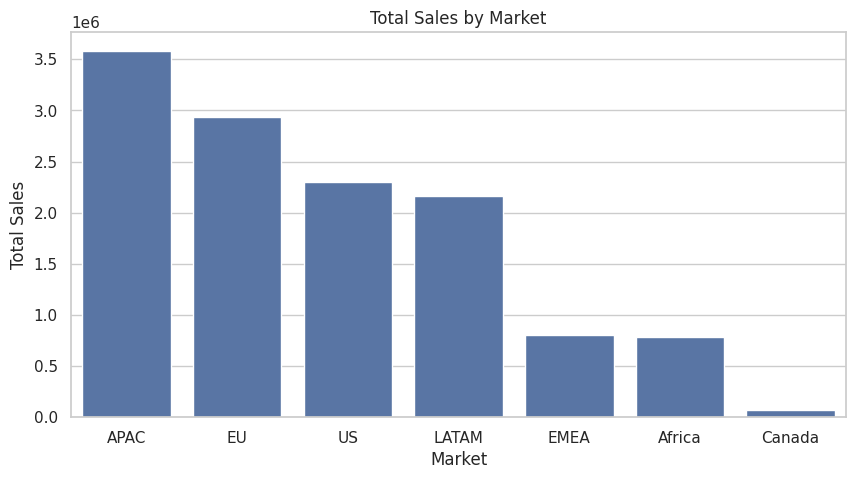

In [16]:
# Sales by market chart
plt.figure(figsize=(10, 5))

sns.barplot(
    data=market_sales,
    x="market",
    y="total_sales",
)

plt.title("Total Sales by Market")
plt.xlabel("Market")
plt.ylabel("Total Sales")
plt.show()

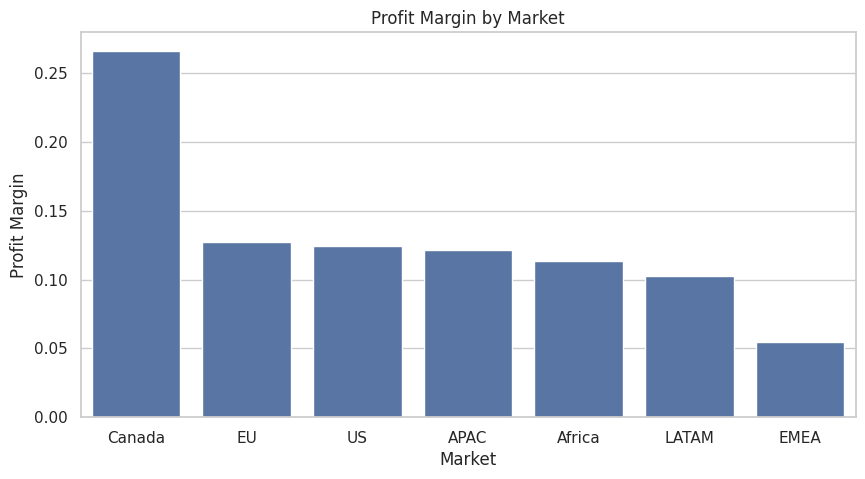

In [17]:
# Profit margin by market chart

plt.figure(figsize=(10, 5))

sns.barplot(
    data=market_sales.sort_values("profit_margin", ascending=False),
    x="market",
    y="profit_margin",
)

plt.title("Profit Margin by Market")
plt.xlabel("Market")
plt.ylabel("Profit Margin")
plt.show()

### Initial market insight

APAC is the strongest market by total sales, followed by EU, US and LATAM.

However, sales volume and profitability are not the same. EMEA has much lower profitability compared with the strongest markets, while LATAM has strong sales volume but a lower margin than APAC, EU and US.

This suggests that the next profitability analysis should focus on markets with high volume but weaker margins.

## 4. Sales by region

Regional analysis gives a more detailed geographic view than market-level analysis.

In [18]:
# sSales by region table

region_sales = sales_by_region(df)

format_sales_table(region_sales)

,region,total_sales,total_profit,total_orders,total_customers,total_quantity,profit_margin,average_order_value
3,Central,"$2,822,399.00","$311,403.98",5249,2077,41762,11.03%,$537.70
10,South,"$1,600,960.00","$140,355.77",3270,1745,25206,8.77%,$489.59
7,North,"$1,248,192.00","$194,597.95",2356,1283,18021,15.59%,$529.79
9,Oceania,"$1,100,207.00","$120,089.11",1744,705,12838,10.92%,$630.85
11,Southeast Asia,"$884,438.00","$17,852.33",1517,672,11822,2.02%,$583.02
8,North Asia,"$848,349.00","$165,578.42",1150,617,8851,19.52%,$737.69
5,EMEA,"$806,184.00","$43,897.97",2462,760,11517,5.45%,$327.45
0,Africa,"$783,776.00","$88,871.63",2232,754,10564,11.34%,$351.15
4,Central Asia,"$752,839.00","$132,480.19",1026,570,7715,17.60%,$733.76
12,West,"$725,514.00","$108,418.45",1611,686,12266,14.94%,$450.35


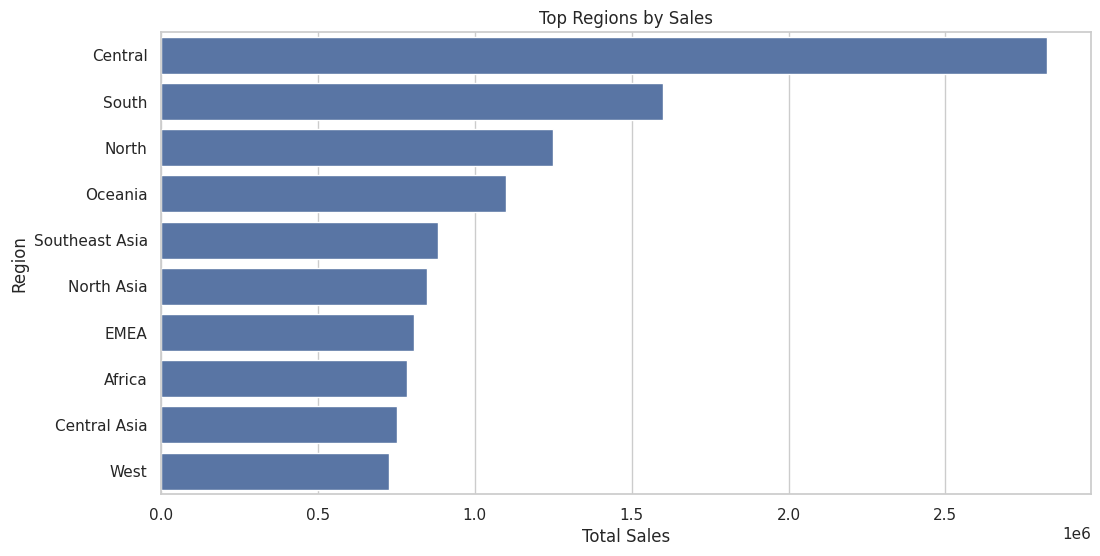

In [19]:
# Top regions by sales chart

top_regions = region_sales.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_regions,
    y="region",
    x="total_sales",
)

plt.title("Top Regions by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.show()

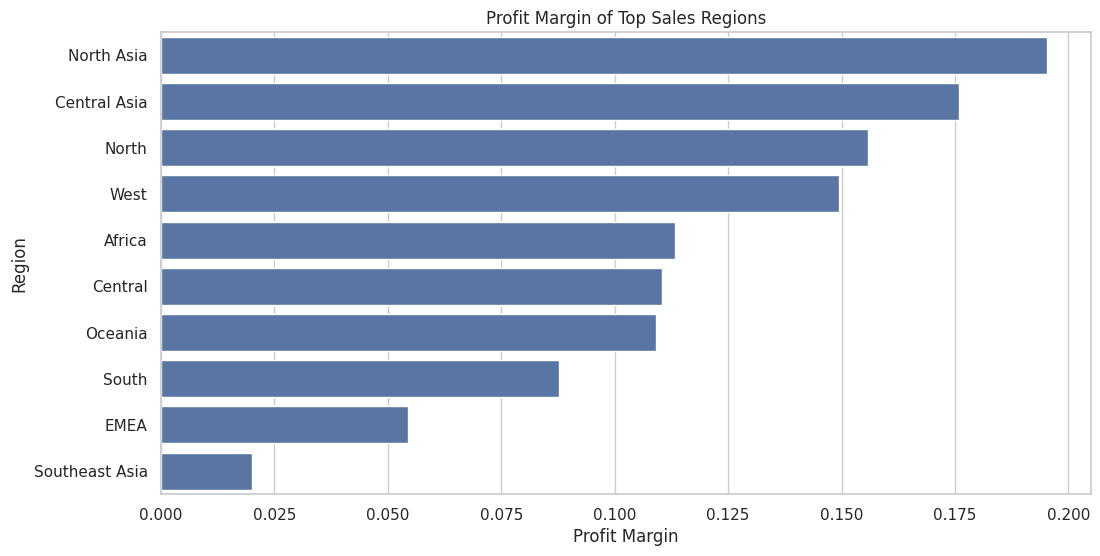

In [20]:
# Profit margin by region chart

top_regions_by_sales = region_sales.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_regions_by_sales.sort_values("profit_margin", ascending=False),
    y="region",
    x="profit_margin",
)

plt.title("Profit Margin of Top Sales Regions")
plt.xlabel("Profit Margin")
plt.ylabel("Region")
plt.show()

### Initial regional insight

Central is the top region by sales volume, but North has a stronger profit margin.

Southeast Asia is an important warning signal: it appears among the top sales regions, but its profit margin is very low. This suggests that high sales volume in this region may not be translating into strong profitability.

## 5. Sales by category

Category analysis helps identify which product groups drive revenue.

In [21]:
# Sales by category table
category_sales = sales_by_category(df)

format_sales_table(category_sales)

,category,total_sales,total_profit,total_orders,total_quantity,total_products,profit_margin,average_order_value
2,Technology,"$4,744,691.00","$663,778.73",8354,35176,2375,13.99%,$567.95
0,Furniture,"$4,110,884.00","$285,204.72",8195,34954,2228,6.94%,$501.63
1,Office Supplies,"$3,787,330.00","$518,473.83",19003,108182,5689,13.69%,$199.30


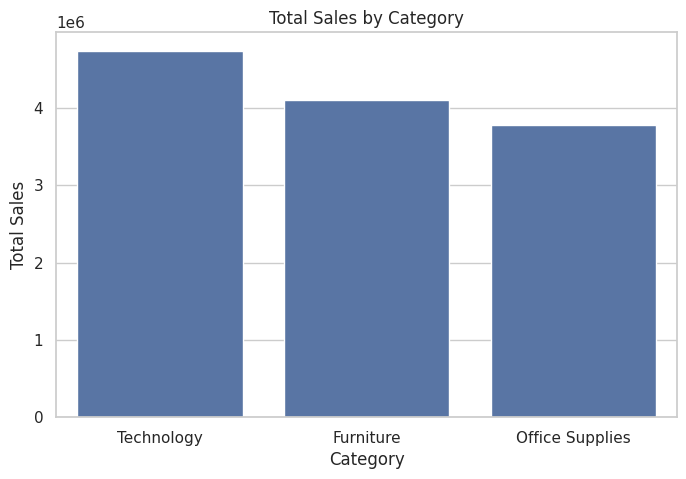

In [22]:
# Sales by category chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_sales,
    x="category",
    y="total_sales",
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

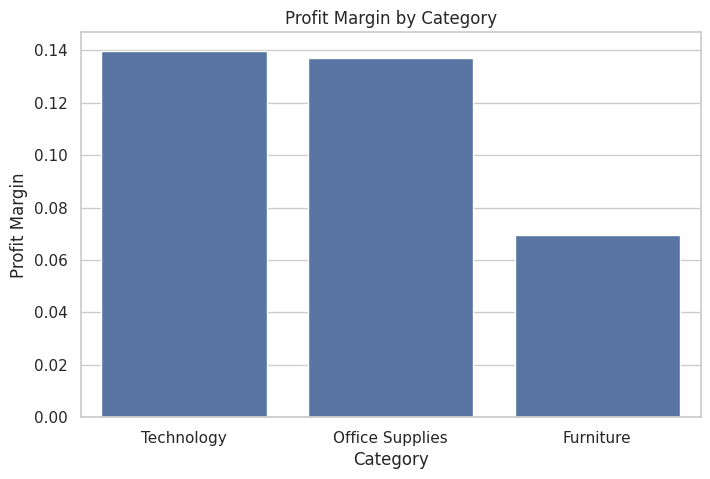

In [23]:
# Profit margin by category chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_sales.sort_values("profit_margin", ascending=False),
    x="category",
    y="profit_margin",
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.show()

### Initial category insight

Technology is the strongest category by sales and profit.

Furniture is a key area of concern. It generates high sales volume, but its profit margin is much lower than Technology and Office Supplies.

Office Supplies sells less than Furniture, but generates significantly higher profit and margin. This means Furniture should be reviewed in the profitability analysis.

## 6. Sales by sub-category

Sub-category analysis helps identify which product lines are driving sales.

In [25]:
# Sales by sub-category table
sub_category_sales = sales_by_sub_category(df)

format_sales_table(sub_category_sales.head(15))

,sub_category,total_sales,total_profit,total_orders,total_quantity,total_products,profit_margin,average_order_value
13,Phones,"$1,706,874.00","$216,717.01",3133,11870,692,12.70%,$544.80
6,Copiers,"$1,509,439.00","$258,567.55",2120,7454,520,17.13%,$712.00
5,Chairs,"$1,501,682.00","$140,396.27",3187,12336,619,9.35%,$471.19
4,Bookcases,"$1,466,559.00","$161,924.42",2284,8310,559,11.04%,$642.10
14,Storage,"$1,127,124.00","$108,461.49",4534,16917,648,9.62%,$248.59
1,Appliances,"$1,011,081.00","$141,680.59",1686,6078,558,14.01%,$599.69
11,Machines,"$779,071.00","$58,867.87",1422,4906,499,7.56%,$547.87
16,Tables,"$757,034.00","$-64,083.39",836,3083,366,-8.47%,$905.54
0,Accessories,"$749,307.00","$129,626.31",2889,10946,664,17.30%,$259.37
3,Binders,"$461,952.00","$72,449.85",5392,21429,742,15.68%,$85.67


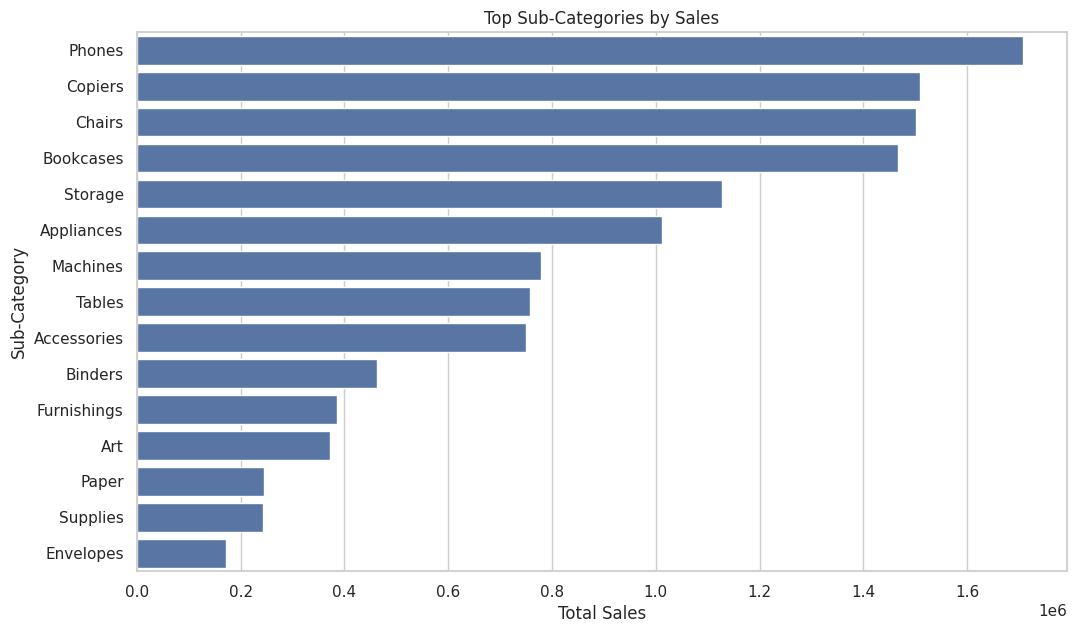

In [26]:
# Top sub-categories by sales chart
top_sub_categories = sub_category_sales.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_sub_categories,
    y="sub_category",
    x="total_sales",
)

plt.title("Top Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()

### Initial sub-category insight

Top-selling sub-categories help explain which product lines drive revenue.

However, this list should not be interpreted as a list of best-performing products financially. In the profitability notebook, these sub-categories must be compared against profit and margin to identify high-volume but low-margin product lines.

## 7. Sales by customer segment

Segment analysis helps understand which customer groups drive business volume.

In [27]:
# Sales by segment table

segment_sales = sales_by_segment(df)

format_sales_table(segment_sales)

,segment,total_sales,total_profit,total_orders,total_customers,total_quantity,profit_margin,average_order_value
0,Consumer,"$6,508,141.00","$749,239.78",13104,2509,92157,11.51%,$496.65
1,Corporate,"$3,824,808.00","$441,208.33",7673,1457,53565,11.54%,$498.48
2,Home Office,"$2,309,956.00","$277,009.18",4687,907,32590,11.99%,$492.84


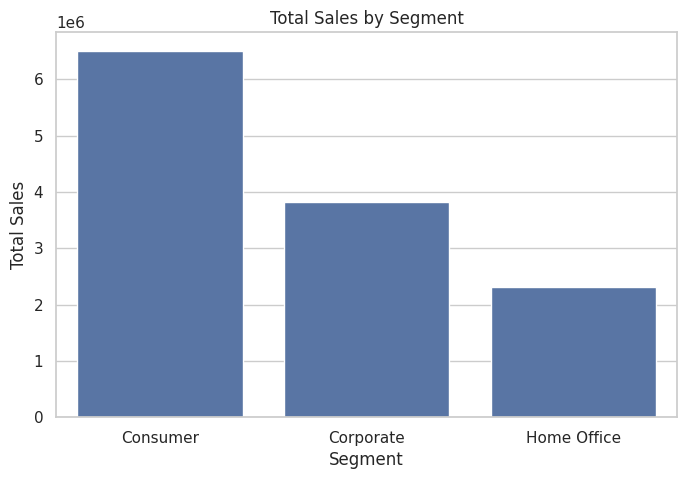

In [28]:
# Sales by segment chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_sales,
    x="segment",
    y="total_sales",
)

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

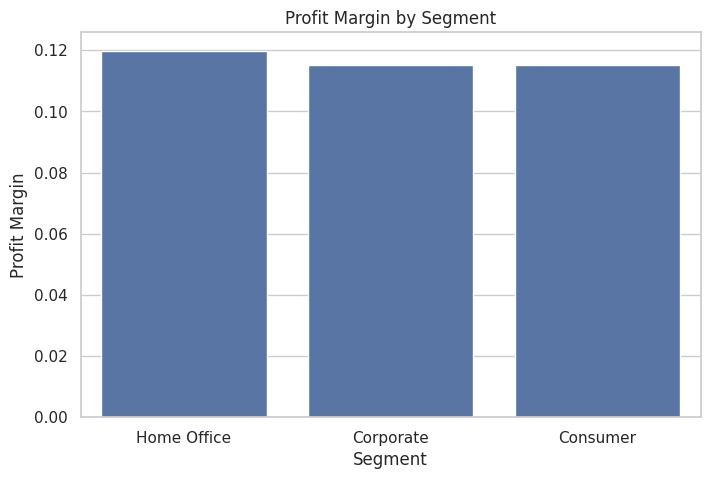

In [29]:
# Profit margin by segment chart

plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_sales.sort_values("profit_margin", ascending=False),
    x="segment",
    y="profit_margin",
)

plt.title("Profit Margin by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit Margin")
plt.show()

### Initial segment insight

Consumer is the largest segment by sales, orders and quantity.

However, profit margins are very similar across Consumer, Corporate and Home Office. Home Office has a slightly higher margin, but lower sales volume.

This suggests that segment performance is relatively balanced, and deeper analysis should focus more on market, region, category, discounts and logistics.

## 8. Top products by sales

Top products by sales show which products generate the highest revenue.

However, some top-selling products may have weak or negative profit margins.

In [30]:
# Top products table
top_sales_products = top_products_by_sales(df, top_n=15)

format_sales_table(top_sales_products)

,product_id,product_name,category,sub_category,total_sales,total_profit,total_orders,total_quantity,profit_margin
9388,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"$61,600.00","$25,199.93",5,20,40.91%
10632,TEC-PH-10004664,"Nokia Smart Phone, with Caller ID",Technology,Phones,"$30,042.00","$5,455.95",10,52,18.16%
4017,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,"$27,454.00","$7,753.04",10,31,28.24%
9721,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,"$22,638.00","$-1,811.08",1,6,-8.00%
10646,TEC-PH-10004823,"Nokia Smart Phone, Full Size",Technology,Phones,"$22,261.00","$8,121.48",11,39,36.48%
745,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,"$21,870.00",$0.00,8,39,0.00%
541,FUR-CH-10000027,"SAFCO Executive Leather Armchair, Black",Furniture,Chairs,"$21,329.00","$1,363.23",12,50,6.39%
2882,OFF-AP-10004512,"Hoover Stove, Red",Office Supplies,Appliances,"$21,148.00","$10,345.58",7,38,48.92%
3744,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,"$19,824.00","$2,233.51",11,37,11.27%
3634,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,"$19,026.00",$760.98,9,48,4.00%


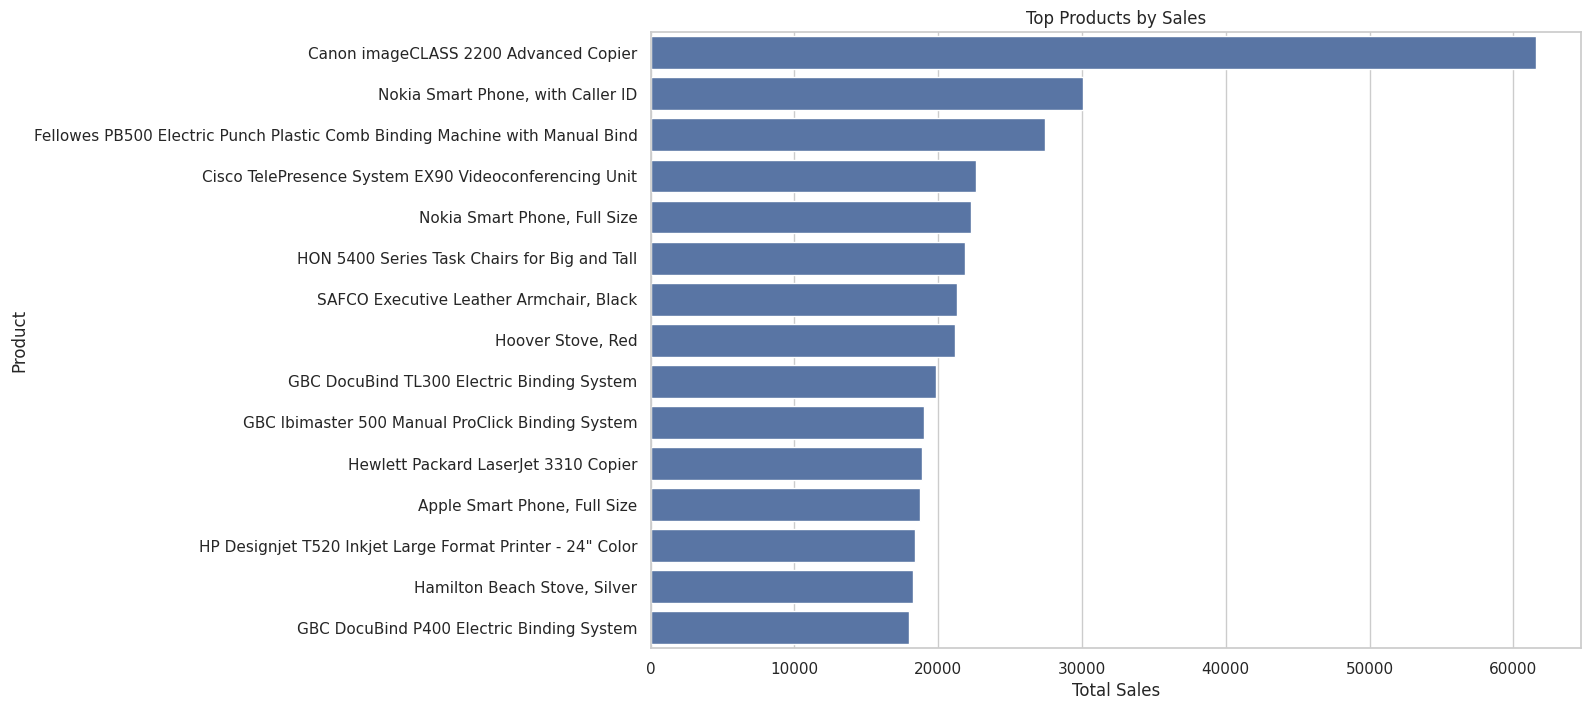

In [31]:
# Top products chart
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_sales_products,
    y="product_name",
    x="total_sales",
)

plt.title("Top Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

In [32]:
# Top products with weak margins
top_sales_products[
    top_sales_products["profit_margin"] <= 0.05
][
    [
        "product_name",
        "category",
        "sub_category",
        "total_sales",
        "total_profit",
        "profit_margin",
    ]
]

,product_name,category,sub_category,total_sales,total_profit,profit_margin
9721,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638,"-1,811.0784",-0.0800
745,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870,0.0000,0.0000
3634,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19026,760.9800,0.0400
4214,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965,"-1,878.1662",-0.1045


### Initial product insight

Some top-selling products may have weak or negative margins.

This is a critical business signal: high revenue does not always mean strong profitability. Products with high sales and low margins should be reviewed for discount strategy, pricing, shipping costs or procurement costs.

## Sales analysis conclusion

The sales analysis shows strong and consistent business growth from 2011 to 2014.

Key findings:

- Sales, profit, orders and quantity increased every year.
- APAC is the leading market by sales.
- Central is the leading region by sales.
- Technology is the top category by both sales and profit.
- Furniture generates high sales but has a much weaker margin.
- Consumer is the largest customer segment by volume.
- Some top-selling products have weak or negative margins.

Main business implication:

The business should not evaluate performance by sales volume alone. Several areas with strong sales show weaker profitability, especially Furniture, Southeast Asia and some top-selling products.

Next step:

The next notebook should focus on profitability to answer:

- Which categories and sub-categories generate the most profit?
- Which products destroy margin?
- Which regions sell a lot but generate low profit?
- What explains loss-making orders?